# Notebook 2 — Exploración de Datos (EDA)

Visualiza señales EMG crudas, segmentadas y filtradas.

In [1]:
import os, sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    import glob
    paths = glob.glob('/content/drive/**/emg-classification-knn-svm-ann', recursive=True)
    pc = [p for p in paths if 'Othercomputers' in p or 'Ordenadores' in p]
    PROJECT_PATH = sorted(pc or paths, key=len)[0] if paths else '/content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann'
    os.chdir(PROJECT_PATH)
    sys.path.insert(0, PROJECT_PATH)
except:
    if 'notebooks' in os.getcwd(): os.chdir('..')
    sys.path.insert(0, os.getcwd())

print('CWD:', os.getcwd())


Mounted at /content/drive
CWD: /content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann


In [2]:
from src.config import Config
from src.preprocessing import preprocess_pipeline, bandpass_filter, segment_gesture
from src.visualization import plot_signal

# Cargar DataFrame del Notebook 1
db_path = Config.PROCESSED_DIR / 'notebook1' / 'samples_full.pkl'
df = pd.read_pickle(db_path)
print(f'Dataset cargado: {len(df)} muestras.')
df.head(3)


Dataset cargado: 18750 muestras.


,user_id,split,sample_key,gesture_name,signal_len,n_channels,signal_raw,ground_truth,ground_truth_index
0,user1,train_samples,idx_26,fist,996,8,"[[2.0, -8.0, -2.0, -1.0, 0.0, 0.0, 1.0, 0.0], ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[529, 716]"
1,user1,train_samples,idx_27,fist,996,8,"[[-2.0, -7.0, -2.0, -4.0, -1.0, 0.0, 1.0, 0.0]...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[227, 395]"
2,user1,train_samples,idx_28,fist,992,8,"[[0.0, -1.0, -5.0, -4.0, -1.0, 0.0, -1.0, 0.0]...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[609, 778]"


In [3]:
# Resumen de muestras por gesto y split
resumen = df.groupby(['gesture_name','split']).size().unstack(fill_value=0)
display(resumen)


split,test_samples,train_samples
gesture_name,,
fist,1250,2500
open,1250,2500
pinch,1250,2500
waveIn,1250,2500
waveOut,1250,2500


Gesto: fist  |  Señal completa: (996, 8)


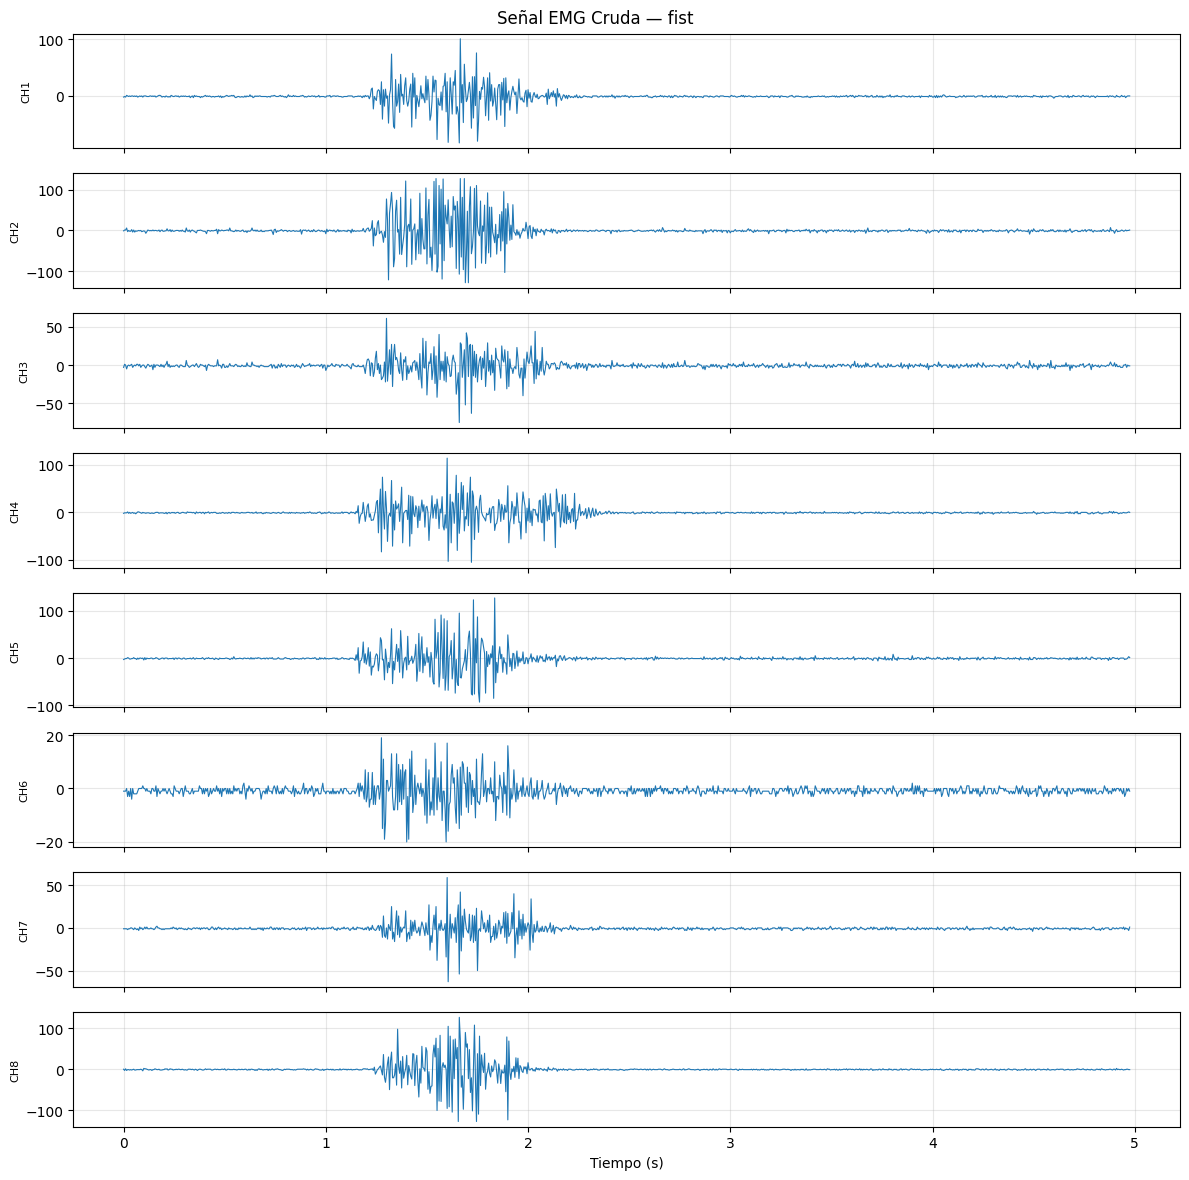

In [4]:
# Seleccionar una muestra al azar y visualizarla
sample = df.sample(1, random_state=42).iloc[0]
signal_raw   = sample['signal_raw']        # shape [T, 8]
gt_idx       = sample['ground_truth_index'] # [inicio, fin]
gesture      = sample['gesture_name']

print(f"Gesto: {gesture}  |  Señal completa: {signal_raw.shape}")
fig = plot_signal(signal_raw, title=f'Señal EMG Cruda — {gesture}', fs=Config.SAMPLE_RATE)
plt.show()


Señal recortada: (230, 8)  |  Filtrada: (230, 8)


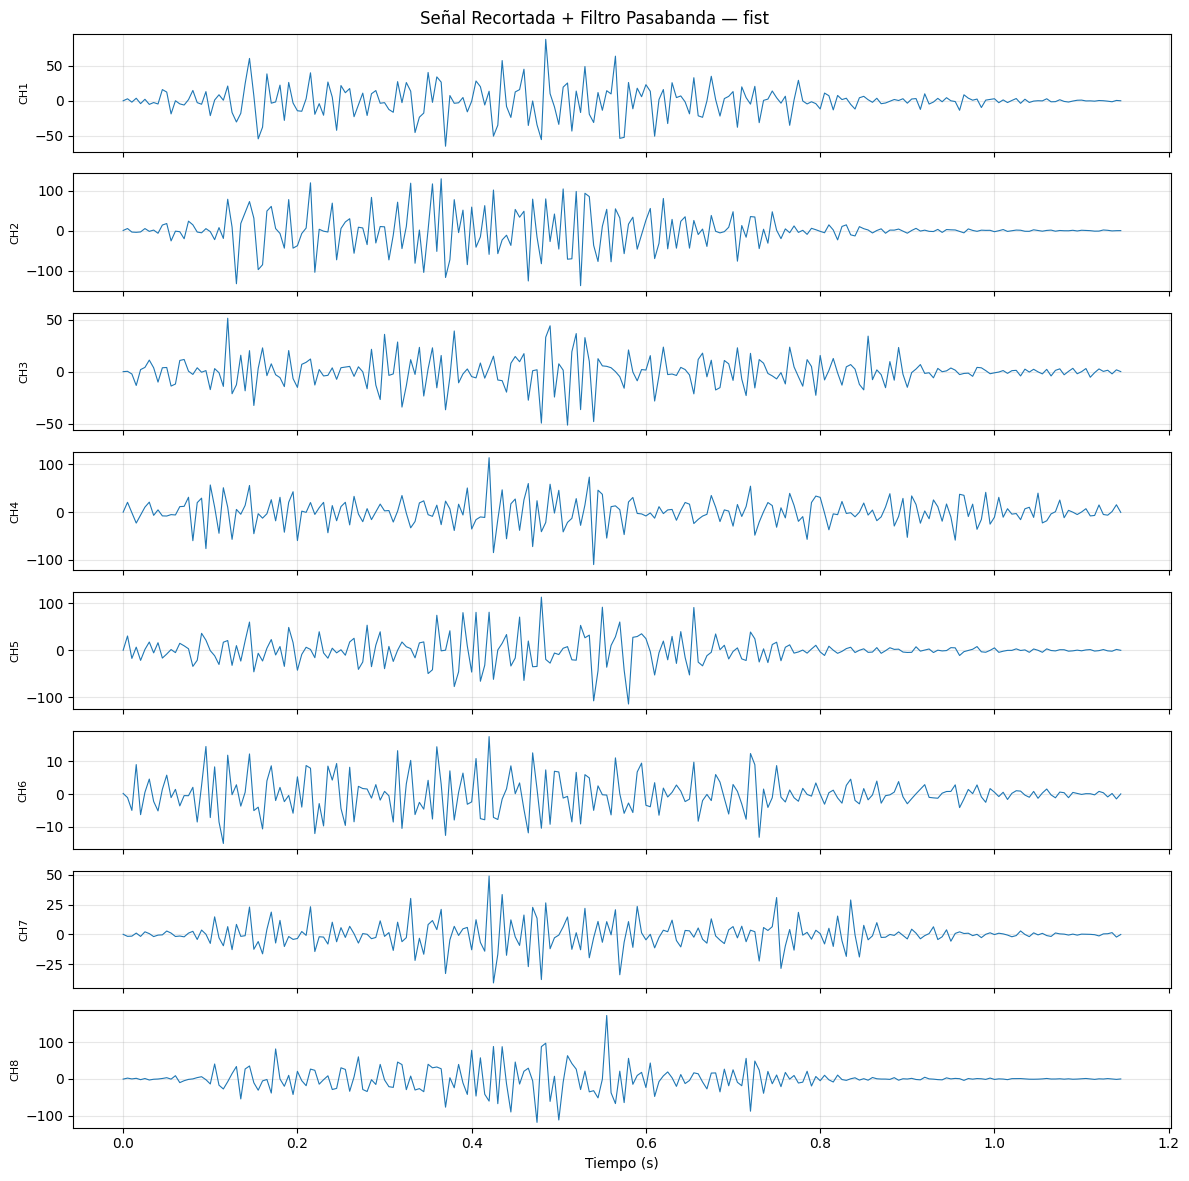

In [5]:
# Señal recortada (solo la acción) y filtrada
signal_seg = segment_gesture(signal_raw, gt_idx)
signal_filt = bandpass_filter(signal_seg)
print(f'Señal recortada: {signal_seg.shape}  |  Filtrada: {signal_filt.shape}')
fig2 = plot_signal(signal_filt, title=f'Señal Recortada + Filtro Pasabanda — {gesture}', fs=Config.SAMPLE_RATE)
plt.show()
